In [ ]:
# import necessary libraries
import pandas as pd 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
# Path to the required data to analyse
open_source_model_results_path = "/Users/jisha/Desktop/Sarcasm_Final/Data_Labelling/outputs.csv"
gemini_result_path = "/Users/jisha/Desktop/Sarcasm_Final/Data_Labelling/gemini.csv"
chatgpt_resukts_path = "/Users/jisha/Desktop/Sarcasm_Final/Data_Labelling/chatgpt.csv"

In [ ]:
# Read data to pandas data frame  data_one
data_one = pd.read_csv(open_source_model_results_path)
data_one.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label           906 non-null    int64 
 1   comment         906 non-null    object
 2   author          906 non-null    object
 3   subreddit       906 non-null    object
 4   score           906 non-null    int64 
 5   ups             906 non-null    int64 
 6   downs           906 non-null    int64 
 7   date            906 non-null    object
 8   created_utc     906 non-null    object
 9   parent_comment  906 non-null    object
 10  llama_temp0     906 non-null    int64 
 11  llama_temp1     906 non-null    int64 
 12  ds_temp0        906 non-null    int64 
 13  ds_temp1        906 non-null    int64 
dtypes: int64(8), object(6)
memory usage: 99.2+ KB


In [ ]:
# Read data to pandas data frame  data_two

data_two = pd.read_csv(gemini_result_path)
data_two.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   comment         906 non-null    object
 1   parent_comment  906 non-null    object
 2   author          906 non-null    object
 3   gemini_label    906 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 28.4+ KB


In [ ]:
# match the contents inside the author column and parent_comment column to merge the data inside the opensource and closed source - gemini results
Comment_authors_name_match = (data_one['author'].values == data_two['author'].values).all()
comment_content_match = (data_one['parent_comment'].values == data_two['parent_comment'].values).all()

if Comment_authors_name_match and comment_content_match:
  
    labeled_column_name = data_two.columns[-1]
    
    data_one[labeled_column_name] = data_two.iloc[:, -1].values
    print(f"Column '{labeled_column_name}' was added to dataset containing labels from opensource models.")
else:
    print("Error: The rows in the first and second dataset do not match based on author and parent_comment.")

Column 'gemini_label' was added to dataset containing labels from opensource models.


In [6]:
data_one.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label           906 non-null    int64 
 1   comment         906 non-null    object
 2   author          906 non-null    object
 3   subreddit       906 non-null    object
 4   score           906 non-null    int64 
 5   ups             906 non-null    int64 
 6   downs           906 non-null    int64 
 7   date            906 non-null    object
 8   created_utc     906 non-null    object
 9   parent_comment  906 non-null    object
 10  llama_temp0     906 non-null    int64 
 11  llama_temp1     906 non-null    int64 
 12  ds_temp0        906 non-null    int64 
 13  ds_temp1        906 non-null    int64 
 14  gemini_label    906 non-null    int64 
dtypes: int64(9), object(6)
memory usage: 106.3+ KB


In [ ]:
# Read data to pandas data frame  data_three

data_three = pd.read_csv(chatgpt_resukts_path)
data_three.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   comment         906 non-null    object
 1   parent_comment  906 non-null    object
 2   author          906 non-null    object
 3   chatgpt_label   906 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 28.4+ KB


In [ ]:
# match the contents inside the author column and parent_comment column to merge the data inside the opensource and closed source chatgpt results

Comment_authors_name_match = (data_one['author'].values == data_three['author'].values).all()
comment_content_match = (data_one['parent_comment'].values == data_three['parent_comment'].values).all()

if Comment_authors_name_match and comment_content_match:
    labeled_column_name = data_three.columns[-1]
    
    data_one[labeled_column_name] = data_three.iloc[:, -1].values
    print(f"Column '{labeled_column_name}' was added to dataset containing labels from opensource models.")
else:
    print("Error: The rows in the first and second dataset do not match based on author and parent_comment.")

Column 'chatgpt_label' was added to dataset containing labels from opensource models.


In [9]:
data_one.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label           906 non-null    int64 
 1   comment         906 non-null    object
 2   author          906 non-null    object
 3   subreddit       906 non-null    object
 4   score           906 non-null    int64 
 5   ups             906 non-null    int64 
 6   downs           906 non-null    int64 
 7   date            906 non-null    object
 8   created_utc     906 non-null    object
 9   parent_comment  906 non-null    object
 10  llama_temp0     906 non-null    int64 
 11  llama_temp1     906 non-null    int64 
 12  ds_temp0        906 non-null    int64 
 13  ds_temp1        906 non-null    int64 
 14  gemini_label    906 non-null    int64 
 15  chatgpt_label   906 non-null    int64 
dtypes: int64(10), object(6)
memory usage: 113.4+ KB


In [10]:
# Save the combined results to csv file 
data_one.to_csv("/Users/jisha/Desktop/Sarcasm_Final/Data_Labelling/data_labeling.csv",index = False)

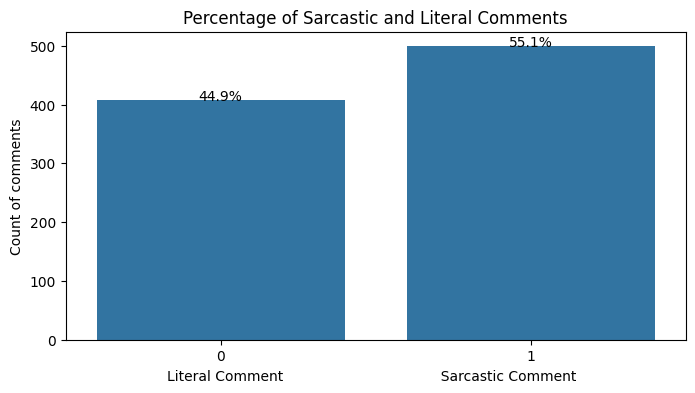

In [ ]:
# Visualise the data imabalnce in the final dataset
plt.figure(figsize=(8, 4))

ax = sns.countplot(data=data_one, x="label")

total_entries_in_the_data = len(data_one)

for p in ax.patches:
    percentage_of_classes = 100 * p.get_height() / total_entries_in_the_data
    ax.text(p.get_x() + p.get_width()/2,
            p.get_height(),
            f'{percentage_of_classes:.1f}%',
            ha='center')

plt.title("Percentage of Sarcastic and Literal Comments")
plt.xlabel("Literal Comment                                    Sarcastic Comment  ")
plt.ylabel("Count of comments")

plt.show()

In [ ]:
# Model result columns to analyse

model_result_columns = [
    'llama_temp0', 
    'llama_temp1',  
    'ds_temp0', 
    'ds_temp1',
    'gemini_label',
    'chatgpt_label'
]


In [ ]:
# Calculate the evaluation metrics and print the results in a  table
actual_label = data_one['label']

results = []

for model_name in model_result_columns:
    predicted_label = data_one[model_name]
    
    accuracy = accuracy_score(actual_label, predicted_label)
    
    precision = precision_score(actual_label, predicted_label, average='macro', zero_division=0)
    recall = recall_score(actual_label, predicted_label, average='macro', zero_division=0)
    F1_score = f1_score(actual_label, predicted_label, average='macro', zero_division=0)
    

    results.append([
        model_name,
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{F1_score:.4f}",
    ])

Table_column_name = [
    "Model", 
    "Accuracy", 
    "Precision", 
    "Recall", 
    "F1-Score", 
]

print(tabulate(results, headers=Table_column_name, tablefmt="grid"))

+---------------+------------+-------------+----------+------------+
| Model         |   Accuracy |   Precision |   Recall |   F1-Score |
+===============+============+=============+==========+============+
| llama_temp0   |     0.532  |      0.4888 |   0.4947 |     0.4334 |
+---------------+------------+-------------+----------+------------+
| llama_temp1   |     0.532  |      0.5055 |   0.5038 |     0.4752 |
+---------------+------------+-------------+----------+------------+
| ds_temp0      |     0.5916 |      0.5956 |   0.5618 |     0.5342 |
+---------------+------------+-------------+----------+------------+
| ds_temp1      |     0.5839 |      0.583  |   0.5543 |     0.5267 |
+---------------+------------+-------------+----------+------------+
| gemini_label  |     0.4912 |      0.6822 |   0.5369 |     0.3964 |
+---------------+------------+-------------+----------+------------+
| chatgpt_label |     0.8124 |      0.818  |   0.8195 |     0.8123 |
+---------------+------------+----

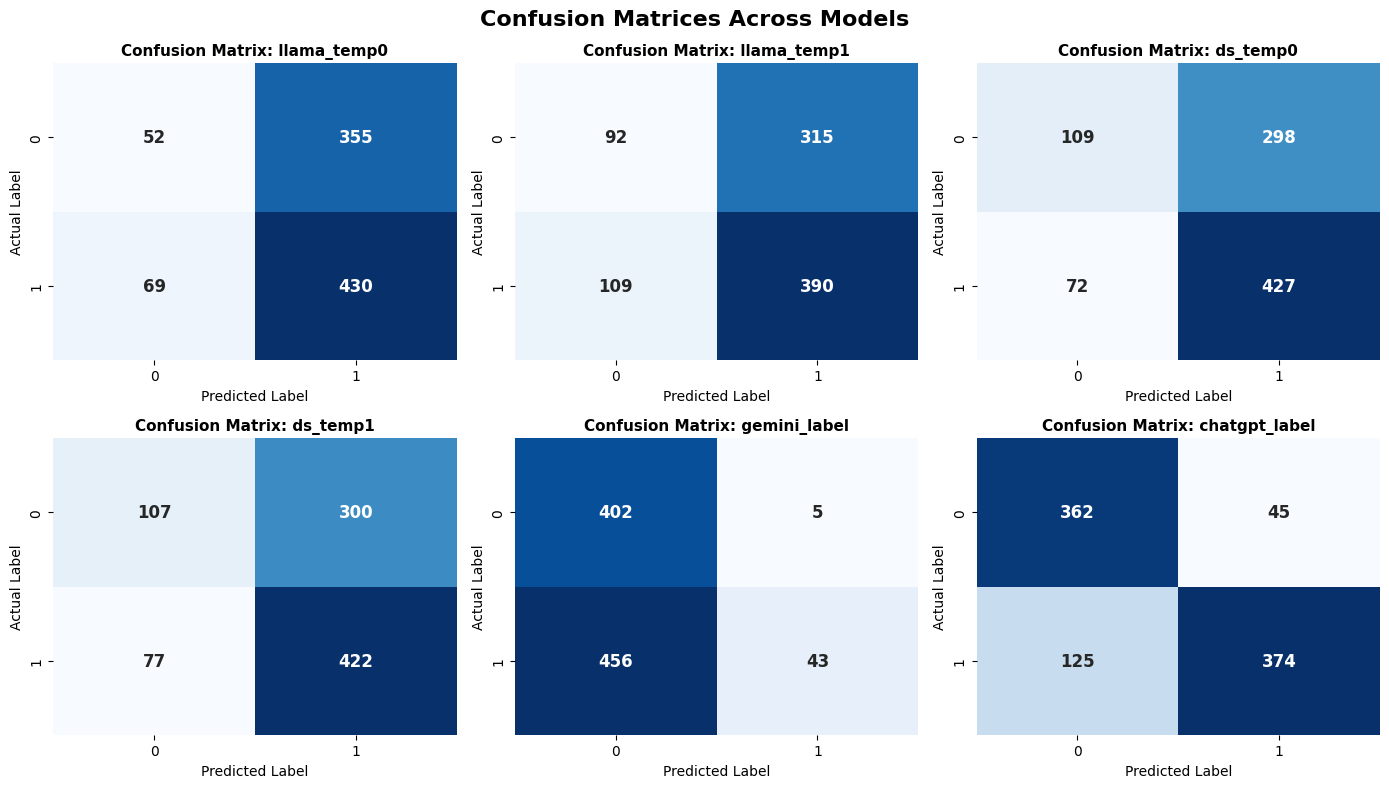

In [ ]:
# Visulaise the confusion matrix
figure, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for index, model in enumerate(model_result_columns):
    ConfusionMatrix = confusion_matrix(data_one["label"], data_one[model])

    sns.heatmap(
        ConfusionMatrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[index],
        cbar=False,
        annot_kws={"size": 12, "weight": "bold"},
    )

    axes[index].set_title(
        f"Confusion Matrix: {model}", fontsize=11, fontweight="bold"
    )
    axes[index].set_xlabel("Predicted Label", fontsize=10)
    axes[index].set_ylabel("Actual Label", fontsize=10)

plt.suptitle("Confusion Matrices Across Models", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
actual_label_column_name = 'label'  
sarcastic_label = 1      
literal_label = 0   

# Compute metrics for both temperatures
def get_metrics(true_label, predicted_label):
    return [
        f1_score(true_label, predicted_label, average='macro'),
        f1_score(true_label, predicted_label, pos_label=sarcastic_label, average='binary'),
        f1_score(true_label, predicted_label, pos_label=literal_label, average='binary'),
        accuracy_score(true_label, predicted_label)
    ]


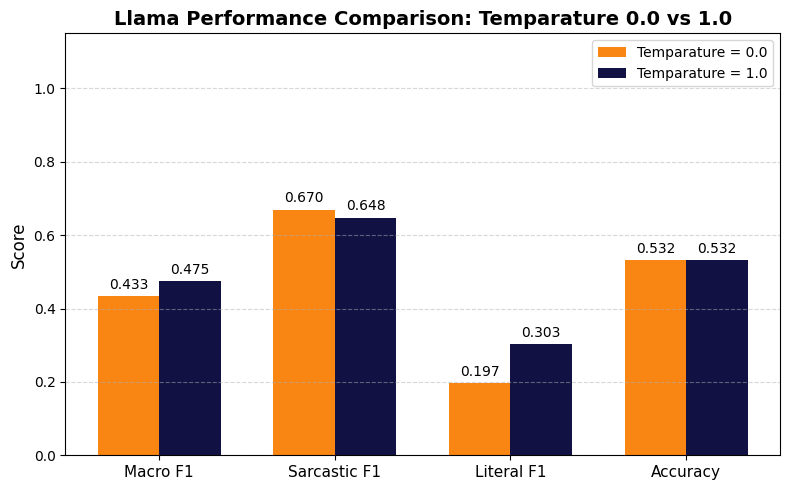

In [ ]:
# Visualise the performance comparison graph of llama model results
actual_label = data_one[actual_label_column_name]
predicted_label_temp0 = data_one['llama_temp0']
predicted_label_temp1 = data_one['llama_temp1']


metrics = ['Macro F1', 'Sarcastic F1', 'Literal F1', 'Accuracy']
temp0_scores = get_metrics(actual_label, predicted_label_temp0)
temp1_scores = get_metrics(actual_label, predicted_label_temp1)

# Plot grouped bar chart
x_axis_position = np.arange(len(metrics))
width_of_bar = 0.35

figure, ax = plt.subplots(figsize=(8, 5))
bar1 = ax.bar(x_axis_position - width_of_bar/2, temp0_scores, width_of_bar, label='Temparature = 0.0', color='#F98513')
bar2 = ax.bar(x_axis_position + width_of_bar/2, temp1_scores, width_of_bar, label='Temparature = 1.0', color='#111144')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Llama Performance Comparison: Temparature 0.0 vs 1.0', fontsize=14, fontweight='bold')
ax.set_xticks(x_axis_position)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
ax.bar_label(bar1, padding=3, fmt='%.3f')
ax.bar_label(bar2, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()

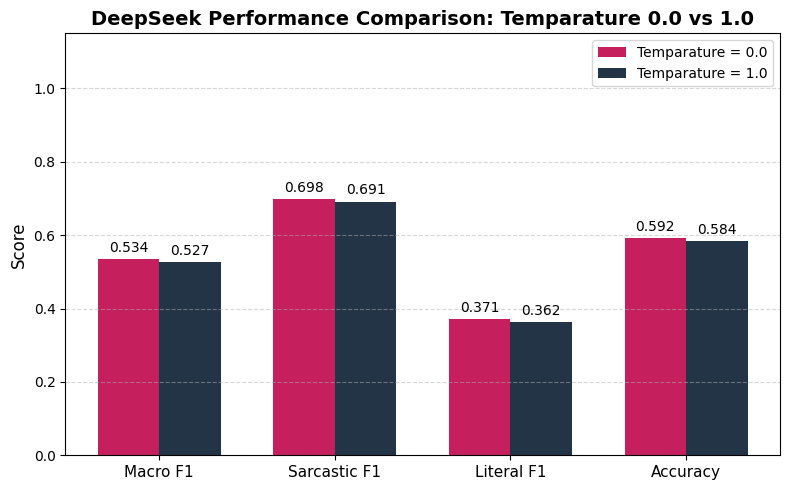

In [ ]:
# Visualise the performance comparison graph of deepseek model results

actual_label = data_one[actual_label_column_name]
predicted_label_temp0 = data_one['ds_temp0']
predicted_label_temp1 = data_one['ds_temp1']


metrics = ['Macro F1', 'Sarcastic F1', 'Literal F1', 'Accuracy']
temp0_scores = get_metrics(actual_label, predicted_label_temp0)
temp1_scores = get_metrics(actual_label, predicted_label_temp1)

# Plot grouped bar chart
x_axis_position = np.arange(len(metrics))
width_of_bar = 0.35

figure, ax = plt.subplots(figsize=(8, 5))
bar1 = ax.bar(x_axis_position - width_of_bar/2, temp0_scores, width_of_bar, label='Temparature = 0.0', color='#C51F5D')
bar2 = ax.bar(x_axis_position + width_of_bar/2, temp1_scores, width_of_bar, label='Temparature = 1.0', color='#243447')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('DeepSeek Performance Comparison: Temparature 0.0 vs 1.0', fontsize=14, fontweight='bold')
ax.set_xticks(x_axis_position)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
ax.bar_label(bar1, padding=3, fmt='%.3f')
ax.bar_label(bar2, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()